In [1]:
import os, torch
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
torch.cuda.empty_cache()

In [2]:
os.getcwd()
os.chdir("/scratch/jq2uw/edit-skingpt4")
os.getcwd()


'/sfs/weka/scratch/jq2uw/edit-skingpt4'

In [3]:
from types import SimpleNamespace
from pathlib import Path

ROOT = Path("/scratch/jq2uw/edit-skingpt4")
RUN = ROOT / "finetune/run"
RESULTS = ROOT / "finetune/results"
RESULTS.mkdir(exist_ok=True)

# Match main_ft.py args
args = SimpleNamespace(
    model_type="gpt_io",
    unfreeze_vit=False,
    unfreeze_qformer=False,
    retrain=True,
    continue_train=False,
    n_epochs=10,
    init_lr=1e-4,
    prompt_keys=[],    # e.g., ["text_demo", "text_lesion"]
    answer_keys=["text_x_skintype", "text_x_location", "text_y3"],
    no_conv_training=False,
    eval_target="y3",
    keep_system=False,
    temperature=0.0,
    suffix="_test",
)

# Derived flags (same as in main_ft.py)
args.freeze_vit = not args.unfreeze_vit
args.freeze_qformer = not args.unfreeze_qformer
args.use_conv_training = not args.no_conv_training
args.remove_system = not args.keep_system

# Expose args (scripts expect it in globals)
globals()["args"] = args


In [4]:
exec((RUN / "init.py").read_text(), globals())


/home/jq2uw/miniconda3/envs/skingpt4/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing Configs
{'arch': 'skin_gpt_io', 'image_size': 224, 'drop_path_rate': 0, 'use_grad_checkpoint': False, 'vit_precision': 'fp16', 'freeze_vit': True, 'freeze_qformer': True, 'num_query_token': 32, 'llm_model': '/scratch/jq2uw/edit-skingpt4/model_skingpt4/hf_models/Llama-2-13b-chat-hf', 'prompt': '', 'model_type': 'pretrain_llama2_13bchat', 'max_txt_len': 160, 'end_sym': '###', 'use_conv_training': True, 'conv_question': 'Is the lesion malignant or benign, or other?', 'prompt_path': 'model_skingpt4/prompts/alignment_skin.txt', 'prompt_template': '###Human: {} ###Assistant: ', 'ckpt': './model_skingpt4/weights/skingpt4_llama2_13bchat_base_pretrain_stage2.pth'}
Initializing Chat
Loading VIT
Loading VIT Done
Loading Q-Former
Loading Q-Former Done
Loading LLM tokenizer
Loading LLM model


Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.03it/s]


Loading LLM Done
Load 2 training prompts
Prompt Example 
###Human: <Img><ImageHere></Img> Could you describe the skin disease in this image for me? ###Assistant: 
Load BLIP2-LLM Checkpoint: ./model_skingpt4/weights/skingpt4_llama2_13bchat_base_pretrain_stage2.pth
Initialization Finished
--------------------------------------------------
model name: ft_skingpt_io_y3_test
model type: skingpt_io
--------------------------------------------------
pretrained weights ckpt path: ./model_skingpt4/weights/skingpt4_llama2_13bchat_base_pretrain_stage2.pth
finetuned weights ckpt path: ./model_skingpt4/weights/ft_skingpt_io_y3_test.pth
results directory: ./finetune/results/ft_skingpt_io_y3_test
--------------------------------------------------
id_patient: 733
id_filename: 3416
midas_path: 17
midas_path: {'malignant-bcc': 608, 'benign-melanocytic nevus': 578, 'nan': 497, 'benign-other': 421, 'benign-seborrheic keratosis': 242, 'malignant-melanoma': 238, 'malignant-scc': 203, 'malignant-ak': 191, 'm

prompt_keys=[], answer_keys=['text_x_skintype', 'text_x_location', 'text_y3']
prompt_input: ''
answer_output: 'The patient has white skin. The lesion is on the torso. The lesion is malignant.'
image: (3, 224, 224) torch.float32 -1.1667941808700562 1.8472758531570435


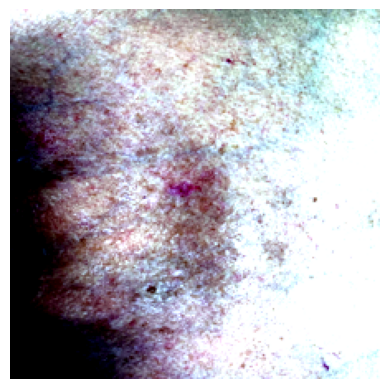

prompt_keys=[], answer_keys=['text_x_skintype', 'text_x_location', 'text_y3']
prompt_input: ''
answer_output: 'The patient has light white skin. The lesion is on the torso. The lesion is benign.'
image: (3, 224, 224) torch.float32 -1.6754751205444336 2.1458969116210938


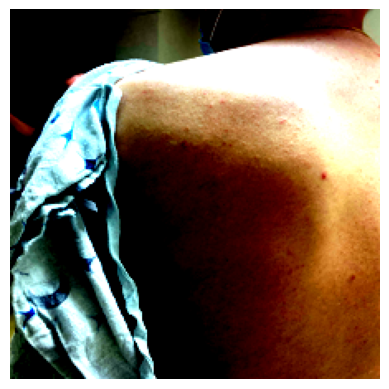

epoch 1/10  train_loss=0.1258  val_loss=0.1133
epoch 2/10  train_loss=0.0916  val_loss=0.1006
epoch 3/10  train_loss=0.0847  val_loss=0.0960
epoch 4/10  train_loss=0.0785  val_loss=0.0880
epoch 5/10  train_loss=0.0711  val_loss=0.0784
epoch 6/10  train_loss=0.0649  val_loss=0.0728

KeyboardInterrupt: saved checkpoint to ./model_skingpt4/weights/ft_skingpt_io_y3_test.pth


In [5]:
exec((RUN / "ft.py").read_text(), globals())

In [ ]:
exec((RUN / "eval.py").read_text(), globals())

--------------------------------------------------
ground truth: malignant
Pretrained model
This is an image of a person's leg. The person is wearing a bandage on their leg. The bandage appears to be wrapped around the leg, covering a portion of the skin. The skin on the leg appears to be
###NLL:{"benign":{"avg_nll":6.53125,"num_tokens":3.0,"prob":0.06803696242083215,"sum_nll":19.59375},"malignant":{"avg_nll":4.5390625,"num_tokens":4.0,"prob":0.2864463110220604,"sum_nll":18.15625},"other":{"avg_nll":8.671875,"num_tokens":2.0,"prob":0.6455167265571076,"sum_nll":17.34375}}
Finetuned model (ft_skingpt_io_y3_test)
=== Prompt ===
###Human: <Img><ImageHere></Img> Is the lesion malignant or benign, or other?###Assistant:
The patient has white skin. The lesion is on the arm. The lesion is other.
###NLL:{"benign":{"avg_nll":10.2734375,"num_tokens":3.0,"prob":0.3687616646696117,"sum_nll":30.8203125},"malignant":{"avg_nll":7.6328125,"num_tokens":4.0,"prob":0.4923614199259241,"sum_nll":30.53125},"

: 